[![Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/giordamaug/decouple_emb_lgbm/blob/main/notebook.ipynb)

## Libraries

In [1]:
import torch
import pandas as pd
import numpy as np
import warnings
warnings.simplefilter(action='ignore')
import numpy as np
import os
import random
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"       # to force BERT determinsm

def set_seed(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # per multi-GPU
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True)

## Load dataset

In [3]:
import sys
sys.path.append('.')
from scripts.utils import Settings

dataset = "MIMIC"
if dataset == "INA":
    datafile =  "data/dataset_14_04_26_EN_newicd_ccs.json"
    target_var = "is_alive?"
    evfields = ['ccs']
    remove_events = ['followup', 'platelet', 'bmi_change', 'thrombosys']
    no_selection = False
elif dataset == "MIMIC":
    datafile = "mimic-iv_asplenic_4706_ccs.json"
    target_var = "is_alive?"
    evfields = ['ccs']
    remove_events = ['drug']
    no_selection = True
else:
    raise Exception("dataset not supported!")
args = Settings(datafile = datafile, 
                no_selection=no_selection,
                pathology_field = 'base_pathology_area', #'base_pathology_area', # 'primarys_disease'
                static_vars= ["gender", "age_group", "base_pathology_area"],
                target_var = target_var,
                pathologies={'Asplenic Syndromes' : 'AS', 
                            'Autoimmune Hematological Diseases' : 'AIHD', 
                            'Congenital Hemolytic Anemias' : 'CHA', 
                            'Immunodeficiencies' : 'IM', 
                            'NTDT - (Non Transfusion Dependent Thalassemia - Intermediate Thalassemia)' : 'NTDT', 
                            'Non-Hemato-Oncological Causes' : 'NHOC', 
                            'Oncological Diseases' : 'OD', 
                            'SCD - (Sickle Cell Disease, Anemia/Sickle Cell or Sickle Cell Disease)' : 'SCD', 
                            'TDT - (Transfusion Dependent Thalassemia - Thalassemia Major)' : 'TDT'},
                selected_spleen_flags = ['YES'],
                methods=['LSTM', 'GRU', 'GRU-D', 'BEHRT', 'Dipole', 'DOME', 'BINARY'],
                evfields = evfields,
                remove_events = remove_events,
                enable_plot=True, 
                n_splits=5, 
                num_epochs=10, 
                batch_size = 16, 
                embedding_size=128,
                hidden_size=300)

Loaded 887 records from mimic-iv_asplenic_4706_ccs.json


### Remove patients with specific cause of death

In [4]:
if "cause_of_death" in args.dataset.columns:
    words = ["accident", "trauma", "suicide"]
    pattern = "|".join(words)
    args.dataset = args.dataset[~args.dataset["cause_of_death"].str.contains(pattern, case=False, na=False)]
    args.selected_patient_ids = args.dataset.index
    print("Patients no:", len(args.selected_patient_ids))

Patients no: 884


### Remove patients with no events

In [5]:
args.dataset = args.dataset[args.dataset["events"].apply(lambda x: x != [])]
args.selected_patient_ids = args.dataset.index
print("Patients no:", len(args.selected_patient_ids))

Patients no: 884


## Plot patients distribution

In [6]:
args.dataset.columns

Index(['gender', 'age_group', 'is_splenectomized?', 'age_at_splenectomy',
       'base_pathology_area', 'is_alive?', 'cause_of_death', 'events'],
      dtype='object')

Index(['OD - Oncological Diseases', 'SP - Splenectomized',
       'CHA - Congenital Hemolytic Anemias', 'THA - Thalassemia'],
      dtype='object', name='base_pathology_area')


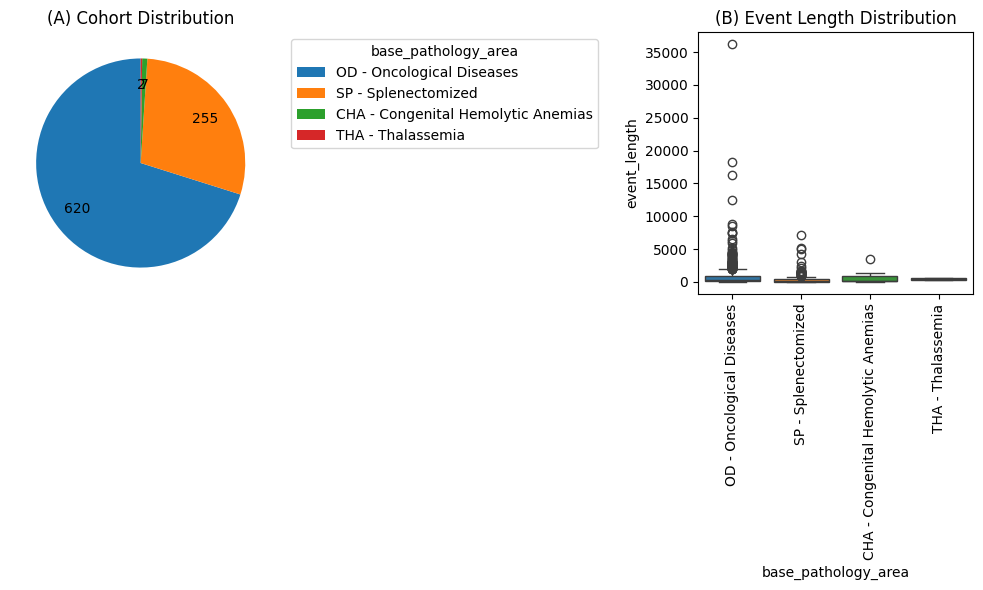

In [7]:
from scripts.utils import plot_group_distribution_with_event_boxplot
plot_group_distribution_with_event_boxplot(args.dataset, groupby=args.pathology_field)#, label_desc=args.pathologies)

## Get clinical trajectories

### count event by type and cardinality

In [8]:
from scripts.utils import count_events_by_type
events_field, date_field, type_field = 'events', 'date', 'type'
event_sequences = { id: [(" ".join([event[field] for field in args.evfields]), event[date_field], event[type_field]) for event in events] for (id,events) in args.dataset[[events_field]].to_dict()[events_field].items()} 
cnt_df = count_events_by_type(event_sequences)
cnt_df

,cardinality,n. instances,set
type,,,
infection,14,3933,{Symptoms; signs; and ill-defined conditions a...
disease,19,63730,{Diseases of the musculoskeletal system and co...
drug,1075,501309,"{DOXOrubicin, Letrozole, Benztropine Mesylate,..."
vaccination,38,68273,"{Fluconazole, Fluorometholone 0.1% Ophth Susp...."
surgery,93,1764,"{Abdominal wall procedures, NEC, Colonoscopy a..."
therapy,193,7393,"{Abdominal wall procedures, NEC, Spinal cord d..."
splenectomy,1,313,{UNKN}


### Remove events by types

n.884 Patients
Index(['OD - Oncological Diseases', 'SP - Splenectomized',
       'CHA - Congenital Hemolytic Anemias', 'THA - Thalassemia'],
      dtype='object', name='base_pathology_area')


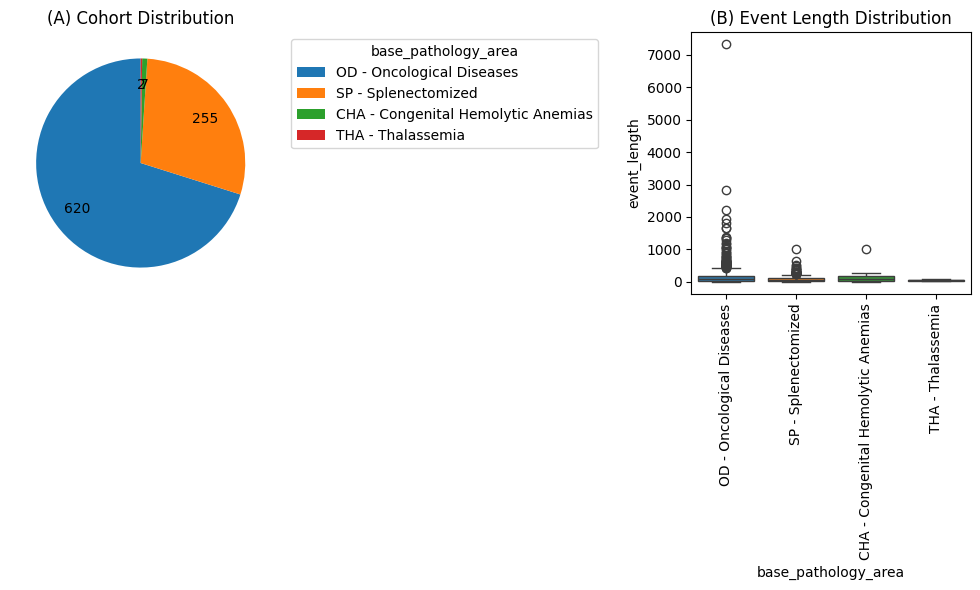

In [9]:
from scripts.utils import group_events_by_visit
# get sequence of event names
event_sequences = { id: [(" ".join([event[field] for field in args.evfields]), event[date_field]) for event in events if event[type_field] not in args.remove_events] for (id,events) in args.dataset[[events_field]].to_dict()[events_field].items()} 
visit_sequences = group_events_by_visit(event_sequences)
args.dataset['events'] = args.dataset.apply(lambda row: event_sequences[row.name], axis=1)
print(f"n.{len(event_sequences)} Patients")
from scripts.utils import plot_group_distribution_with_event_boxplot
plot_group_distribution_with_event_boxplot(args.dataset, groupby=args.pathology_field)#, label_desc=args.pathologies)

### save sequences

In [90]:
import pickle
with open(f'data/{dataset}_events.txt','wb') as f:
      pickle.dump(event_sequences, f)
with open(f'data/{dataset}_visits.txt','wb') as f:
      pickle.dump(visit_sequences, f)

## Get static variables

In [10]:
if len(args.static_vars) > 0:
    mapper = {'pediatric': 0, 'adolescent' : 1, 'adult': 2, 'ND' : -1, 'young': 0, 'mature' : 1, 'elder': 2, 'geriatric': 3}
    X_static = args.dataset.loc[args.selected_patient_ids][args.static_vars].copy()
    X_static.replace(mapper, inplace=True)
    cnames = list(X_static.select_dtypes(include=['object']).columns)
    for col in cnames:
        X_static[col], _ = pd.factorize(X_static[col])
else:
    X_static = pd.DataFrame(index=args.selected_patient_ids)
X_static

,gender,age_group,base_pathology_area
id,,,
10015988,0,3,0
10031816,0,1,1
10036086,0,2,0
10056037,1,2,0
10069400,0,0,1
...,...,...,...
19958502,1,1,0
19962250,0,2,1
19978766,0,1,0


## Get targets

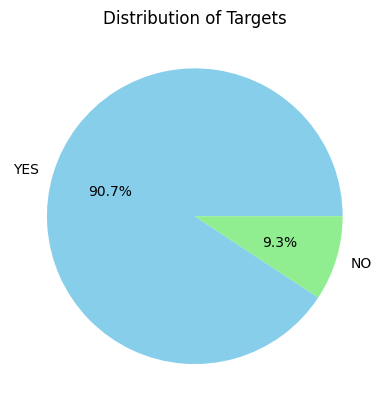

In [11]:
import matplotlib.pyplot as plt
target_df = args.dataset[args.target_var].copy()
target_df.replace({"n/a": "YES", np.nan: "YES"}, inplace=True)
counts = target_df.value_counts()
counts.plot(kind='pie', autopct='%1.1f%%', colors=['skyblue', 'lightgreen'])
plt.title('Distribution of Targets')
plt.ylabel('')
target_df.replace({"YES": 0, "NO": 1}, inplace=True)
target_df.to_csv(f"data/{dataset}_targets.csv")
plt.show()

In [12]:
target_df.value_counts(dropna=False)

is_alive?
0    802
1     82
Name: count, dtype: int64

## Validate

In [13]:
from scripts.configure import configure
embedder_configs = configure(event_sequences, visit_sequences, target_df.to_dict(), X_static, args)

#Create empty dataframe for results collections
cols = ["AUC mean","AUC std","F1 mean","F1 std","Prec mean","Prec std","Recall mean","Recall std","MCC mean","MCC std","Acc mean","Acc std","CM"]
dtypes = {"AUC mean": "float64", "AUC std": "float64","F1 mean": "float64","F1 std": "float64","Prec mean": "float64","Prec std": "float64","Recall mean": "float64","Recall std": "float64","MCC mean": "float64","MCC std": "float64","Acc mean": "float64","Acc std": "float64", "CM": "string"}

# Pre-allocate empty DataFrame with correct dtypes
results_df = pd.DataFrame(
    {c: pd.Series(dtype=dt) for c, dt in dtypes.items()},
    columns=cols
)

In [ ]:
from scripts.cv_folding import lgbm_cv
set_seed(args.random_state)
results_tmp, model, train_df, test_df, y_train, y_test= lgbm_cv(embedder_configs, target_df, args.selected_patient_ids,
                                                                methods=['STATIC', 'BiPadLSTM'])
results_df = pd.concat([results_df, results_tmp],axis=0)
results_df

In [96]:
event_sequences

{1: [('Administration of antibiotics', '2102-09-17'),
  ('Splenectomy', '2102-09-17'),
  ('Administration of thrombolytics and platelet inhibitors', '2102-09-17'),
  ('Administration of thrombolytics and platelet inhibitors', '2102-09-17'),
  ('Pneumococcal polysaccharide vaccine, 23-valent (PPSV23)', '2110-10-21'),
  ('Meningococcal conjugate vaccine, serogroups A, C, Y, W-135', '2113-05-23'),
  ('Haemophilus influenzae type b vaccine, PRP-T conjugate', '2113-05-23'),
  ('Meningococcal conjugate vaccine, serogroups A, C, Y, W-135', '2115-05-28'),
  ('Tonsilectomy and adenoidectomy', '2115-06-14'),
  ('Meningococcal B vaccine, 2-dose schedule', '2115-12-31'),
  ('Pneumonia (except that caused by tuberculosis)', '2116-02-16'),
  ('Influenza virus vaccine, quadrivalent, preservative-free, 0.5 mL dose',
   '2117-10-26')],
 2: [('Administration of thrombolytics and platelet inhibitors', '2132-12-11'),
  ('Splenectomy', '2132-12-11'),
  ('Administration of antibiotics', '2132-12-11')],
 3: 